# Machine Learning 1 Coursework

- To be completed by **5pm** on **Thursday 4 December** and uploaded to the [Coursework submission point](https://moodle.bath.ac.uk/mod/assign/view.php?id=1518353) on Moodle.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def extend_X(Xh):
    """
    Extend all vectors in Xh by 1 in the first component.
    """
    X = np.ones((Xh.size//Xh.shape[-1], Xh.shape[-1]+1))
    X[:, 1:] = Xh
    return X

def softmax(W):
    """
    Compute the softmax function for each row of the input matrix W.
    """
    return np.exp(W) / np.sum(np.exp(W), axis=1, keepdims=True)

def h(Xh, Theta):
    """
    Prediction rule for input data Xh and parameters Theta.
    """
    return softmax(extend_X(Xh) @ Theta)

def loss(Xh, Theta, Y):
    """
    Cross-entropy loss for input data Xh, parameters Theta, and one-hot encoded labels Y.
    """
    return -np.sum(Y * np.log(h(Xh, Theta))) / Xh.shape[0]

def shuffle_split_data(X,Y,Ntest=50):
    """
    Shuffle and split data into training and test sets, with Ntest samples in the test set.
    """
    m = X.shape[0]
    all_range = np.arange(m)  # index array of all data points
    np.random.shuffle(all_range)
    test_range = all_range[:Ntest]  # index array of the test range
    train_range = all_range[Ntest:]  # complement array of the training range
    return X[train_range], Y[train_range], X[test_range], Y[test_range]

def UndersamplingFeatures(Xh):
    """
    Simple undersampling of features by selecting every 100th measurement
    """
    return Xh[:, 700:1700:100]


def OrderClusterLabels(labels, X):
    """
    Order cluster labels by increasing smallest 0th coordinate of x in each cluster.
    labels should contain values between 0 and K-1, where K is the number of clusters.
    """
    K = np.max(labels)+1
    cluster_x0 = [X[(labels==i).nonzero(), 0].min() for i in range(K)]
    reorder = np.arange(K)
    reorder[np.argsort(cluster_x0)] = np.arange(K)
    return reorder[labels]


def test_grad1():
    """ 
    Unit test for grad_loss in Q1
    """
    Xh = np.array([[1]])
    Theta = np.array([[0.5], [1]])
    Y = np.array([[1]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y))<1e-7, "test_grad1 detected a wrong gradient value"

def test_grad2():
    """ 
    Unit test for grad_loss in Q1
    """
    Xh = np.array([[-1]])
    Theta = np.array([[1,0,0], [1,0,0]])
    Y = np.array([[0.5,0,0.5]])
    G_exact = np.array([[-1/6,1/3,-1/6], [1/6,-1/3,1/6]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y) - G_exact)<1e-7, "test_grad2 detected a wrong gradient value"

def test_grad3():
    """ 
    Unit test for grad_loss in Q1
    """
    Xh = np.array([[1,0], [0,1]])
    Theta = np.array([[1,0], [0,1], [0,1]])
    Y = np.array([[0,1], [0.25,0.75]])
    G_exact = np.array([[3/8,-3/8], [1/4,-1/4], [1/8,-1/8]])
    assert np.linalg.norm(grad_loss(Xh, Theta, Y) - G_exact)<1e-7, "test_grad3 detected a wrong gradient value"

In [3]:
# Q1: Gradient Function

def grad_loss(Xh, Theta, Y):
    N = Xh.shape[0]
    H = h(Xh, Theta)
    X = extend_X(Xh)
    G = (X.T @ (H - Y))/N
    return np.array(G)

In [4]:
# Q2: Adjusted Gradient Descent

def agd(Xtrain, Ytrain, Xtest, Ytest, Theta0, t=1, p=100, q=0.999, S=1000, eps=1e-8):
    Theta = Theta0.copy()
    Theta_best = Theta0.copy()
    loss_best = loss(Xtest, Theta_best, Ytest)
    test_losses = []
    s_star = 0

    for s in range(S):

        L_test_s = loss(Xtest, Theta, Ytest)
        test_losses.append(L_test_s)

        if L_test_s < loss_best:
            loss_best = L_test_s
            Theta_best = Theta.copy()
            s_star = s

        if s >= p and L_test_s > q*test_losses[s-p]:
            break

        G = grad_loss(Xtrain, Theta, Ytrain)
        n_plus_one, M = G.shape
        v = sum(G[j][k]**2 for j in range(n_plus_one) for k in range(M))/(n_plus_one*M)
        #v = np.mean(G**2)
        Theta = Theta - t*G/(np.sqrt(v) + eps)
    return Theta_best, s_star, test_losses

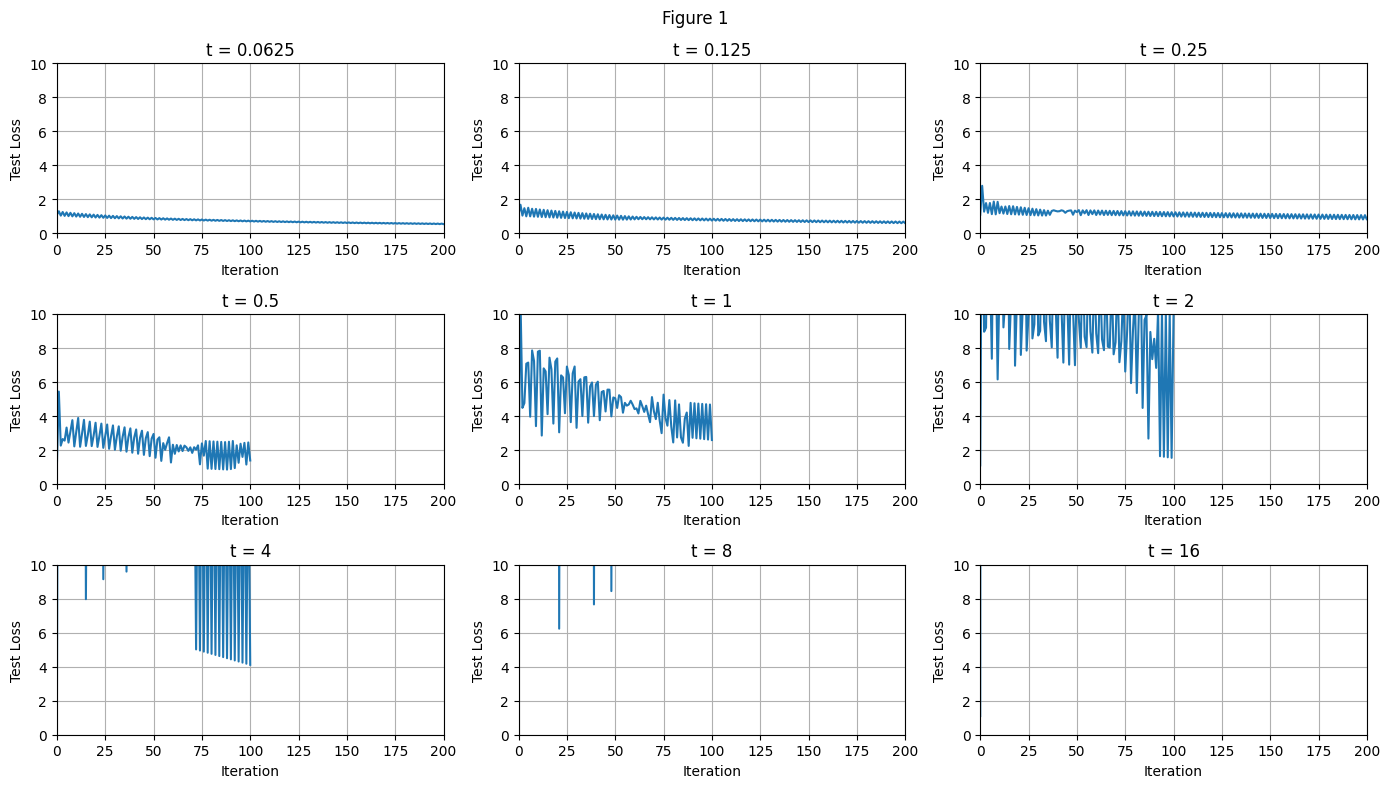

In [27]:
# Q3: Classification of X-Ray Spectra

data = np.load("CWData.npz")
Xh = data["Xh"]
Y = data["Y"]
Xhnew = data["Xhnew"]
Energies = data["Energies"]

Zh = UndersamplingFeatures(Xh)
Zhnew = UndersamplingFeatures(Xhnew)
Ztrain, Ytrain, Ztest, Ytest = shuffle_split_data(Zh, Y, Ntest = 50)

d = Zh.shape[1]
M = Y.shape[1]
Theta0 = np.zeros((d+1,M))

# Finding optimal t
all_test_losses = {}
ts = [1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16]

for t in ts:
    _, _, test_losses = agd(Ztrain, Ytrain, Ztest, Ytest, Theta0, t=t, S=100000)
    all_test_losses[t] = test_losses

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.ravel()

for i, t in enumerate(ts):
    ax = axes[i]
    ax.plot(all_test_losses[t])
    ax.set_title(f"t = {t}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Test Loss")
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 10)
    ax.grid(True)

plt.suptitle('Figure 1')
plt.tight_layout()
plt.show()


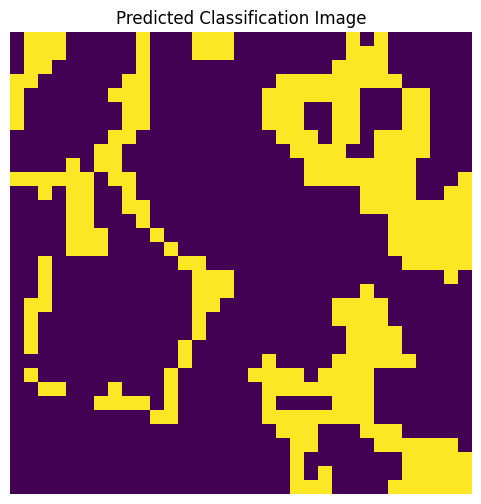

In [29]:
# Q3 Cont.

theta_s_star, _, test_losses = agd(Ztrain, Ytrain, Ztest, Ytest, Theta0, t=0.125, S=100000)

Ynew = h(Zhnew, theta_s_star)
labels = np.argmax(Ynew, axis = 1)
img = labels.reshape(33,33)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Predicted Classification Image")
plt.axis("off")
plt.show()

In [7]:
# Q4: Clustering Features

from sklearn.cluster import KMeans

def ClusterFeaturesFit(K, Xh, Energies):
    E = Energies.reshape(-1,1)
    X_clustering = np.hstack([E, Xh.T])
    kmeans = KMeans(n_clusters=K, n_init=50, max_iter=500).fit(X_clustering)
    labels_ordered = OrderClusterLabels(kmeans.labels_, X_clustering)
    return labels_ordered

def ClusterFeaturesPredict(labels, Xh):
    K = np.max(labels) + 1
    Zh = np.zeros((Xh.shape[0], K))
    for i in range(K):
        cols = Xh[:, labels == i]
        Zh[:, i] = np.mean(cols, axis=1)
    return Zh


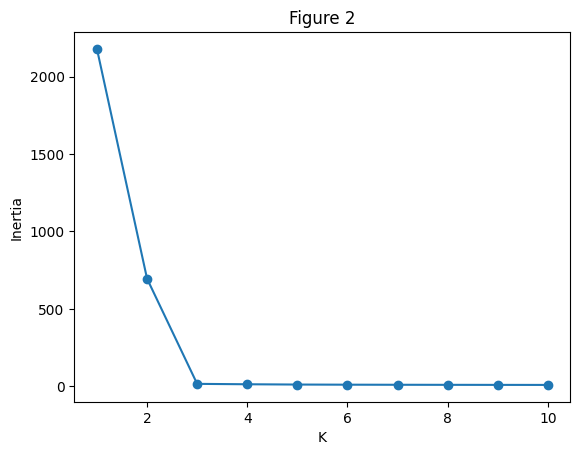

In [30]:
# Q5: Classification with Clustering Features

data = np.load("CWData.npz")
Xh, Y, Xhnew, Energies = data["Xh"], data["Y"], data["Xhnew"], data["Energies"]

# Finding the optimal K
inertias = []
K_values = range(1,11)

for K in K_values:
    kmeans = KMeans(n_clusters=K, n_init=20).fit(Xh)
    inertias.append(kmeans.inertia_)

plt.plot(K_values, inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title('Figure 2')
plt.show()

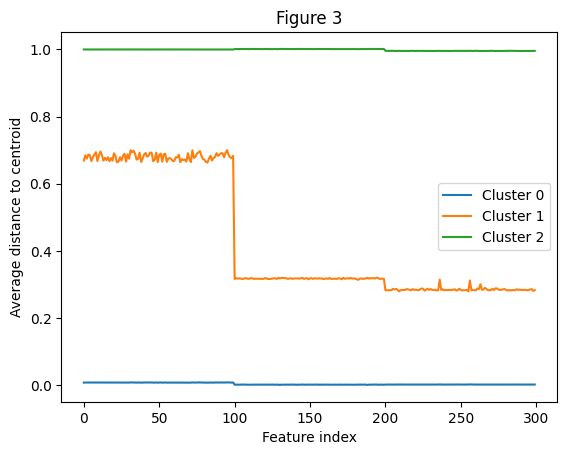

In [31]:
# Q5 Cont.

K = 3

labels = ClusterFeaturesFit(K, Xh, Energies)
Zh = ClusterFeaturesPredict(labels, Xh)
Zhnew = ClusterFeaturesPredict(labels, Xhnew)

# Plotting the clusters
for i in range(K):
    plt.plot(Zh[:, i], label = f"Cluster {i}")

plt.xlabel("Feature index")
plt.ylabel("Average distance to centroid")
plt.legend()
plt.title('Figure 3')
plt.show()

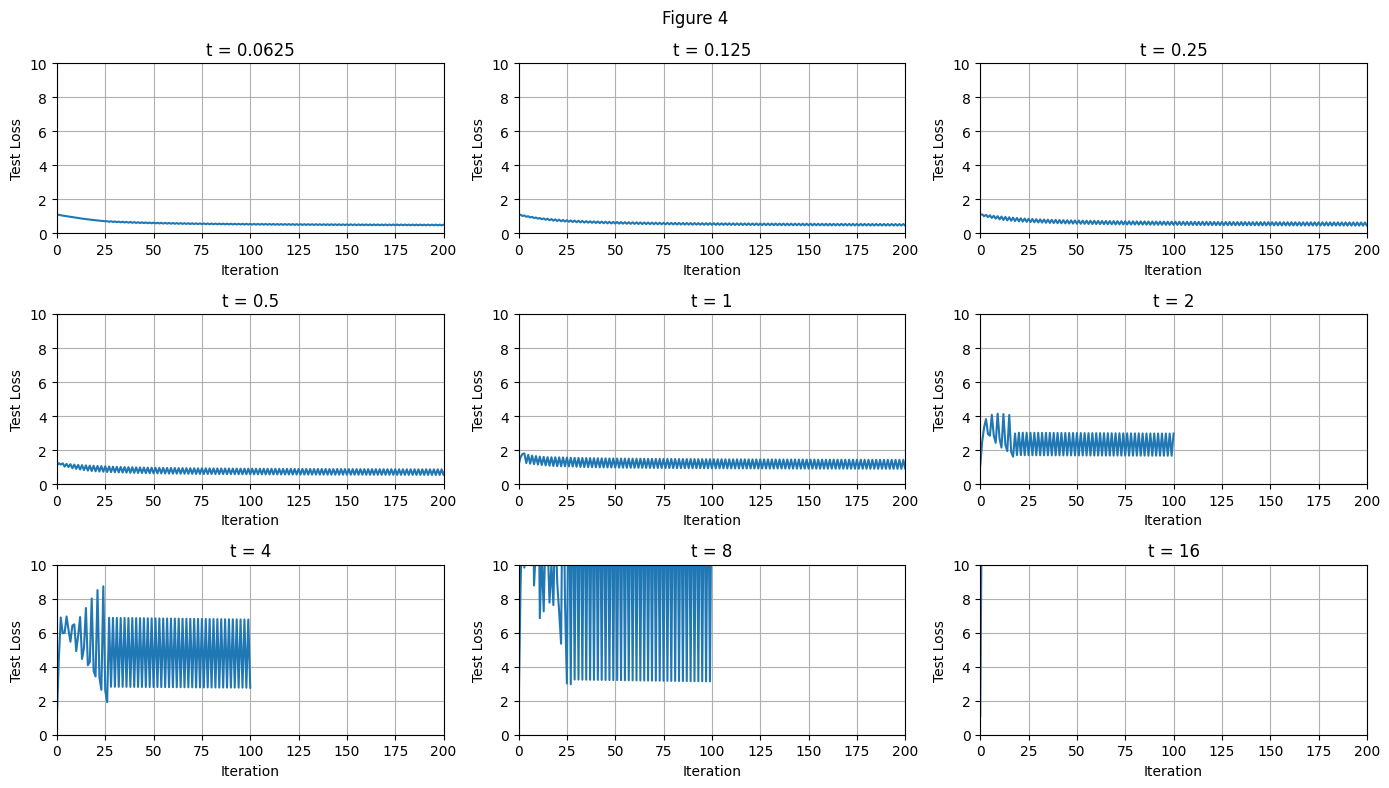

In [ ]:
Ztrain, Ytrain, Ztest, Ytest = shuffle_split_data(Zh, Y, 50)

d = Zh.shape[1]
M = Y.shape[1]
Theta0 = np.zeros((d+1, M))

# Finding the optimal t

all_test_losses = {}
ts = [1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16]

for t in ts:
    _, _, test_losses = agd(Ztrain, Ytrain, Ztest, Ytest, Theta0, t=t, S=5000)
    all_test_losses[t] = test_losses

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.ravel()

for i, t in enumerate(ts):
    ax = axes[i]
    ax.plot(all_test_losses[t])
    ax.set_title(f"t = {t}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Test Loss")
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 10)
    ax.grid(True)

plt.suptitle('Figure 4')
plt.tight_layout()
plt.show()

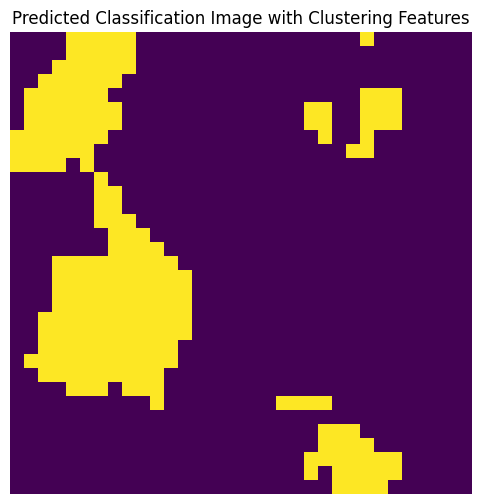

In [37]:
# Q5 Cont.

theta_s_star, _, test_losses = agd(Ztrain, Ytrain, Ztest, Ytest, Theta0, t=1/4, S = 5000)
Ynew = h(Zhnew, theta_s_star)
labels_new = np.argmax(Ynew, axis=1)
img = labels_new.reshape(33,33)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Predicted Classification Image with Clustering Features")
plt.axis("off")
plt.show()